In [77]:
import pandas as pd
import numpy as np
import datetime
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme(palette="Set2")

In [78]:
def random_walk(obs=100, m=0, stdev=0.5, d=1):
    """
    :param: obs: number of observations
    :param: m: mean
    :param: stdev: standard deviation
    :param: d: number of dimensions
    """
    return np.cumsum(np.random.normal(m, stdev, (obs, d)))

def white_noise(obs=100, m=0, stdev=0.5, d=1):
    return np.random.normal(m, stdev, (obs, d)).flatten()

def red_noise(obs=100, m=0, stdev=0.5, d=1, corr=0.7):
    white = white_noise(obs, m, stdev, d)
    red = np.zeros_like(white)
    for i in range(1, len(white)):
        red[i] = corr * red[i-1] + white[i]
    return red

def linear_trend(obs=100, d=1, y_start=0, y_stop=10):
    return np.linspace(start=y_start, stop=y_stop, num=obs).reshape(-1, 1).flatten()

def exp_trend(nobs=100, a=0.001, b=1.01):
    t = np.arange(nobs).reshape(-1, 1).flatten()
    return a * b**t

def log_trend(nobs=100, a=1, b=2):
    t = np.arange(nobs)
    k = (b - 1) / np.log(nobs)
    return a * (1 + k * np.log(1 + t))

def seasonality(obs=100, d=1, period=7, y0=0, y_max=2):
    """
    :param: obs: number of observations
    :param: d: number of dimensions
    :param: period: period of the seasonal component
    :param: y_max: maximum value of the seasonal component
    """
    t = np.arange(obs)
    return y0 + y_max * np.sin(2 * np.pi * t / period).reshape(-1, d).flatten()

def structural_break(t, break_point=50, size=2):
    """:param: t: time points
    :param: break_point: index where the structural break occurs
    """
    t[break_point:] += size 
    return t

def segmented_trend(obs=100, y_start=0, y_stop=10, d=1, 
                    segment_start=0.5, segment_end=0.7, segment_y_start=1, segment_y_stop=5):
    segment_start = int(segment_start*obs)
    segment_end = int(segment_end*obs)
    t1 = linear_trend(segment_start, d, y_start=y_start, y_stop=segment_y_start)
    t2 = linear_trend(segment_end - segment_start, d, y_start=segment_y_start, y_stop=segment_y_stop)
    t3 = linear_trend(obs - segment_end, d, y_start=segment_y_stop, y_stop=y_stop)
    t = np.concatenate([t1, t2, t3])
    return t

def anomalies(t, anomaly_point=70, size=2):
    t[anomaly_point] += size  
    return t

# Additive components

In [79]:
nobs = 365 * 2

# ensure that all values are positive (a requirement for multiplicative models)
rn = red_noise(nobs, m=3)
lt = linear_trend(nobs, y_start=1, y_stop=10)
season = seasonality(nobs, period=90, y0=3, y_max=2)

<Axes: title={'center': 'Additive components'}>

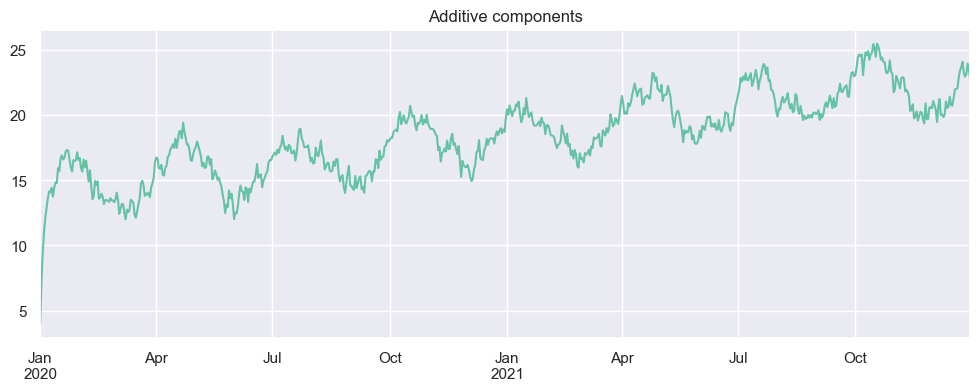

In [80]:
ts = rn + lt + season
dates = pd.date_range(start="01-01-2020", periods=nobs, freq="D") 
df = pd.DataFrame(data=ts, index=dates)
df.plot(figsize=(12, 4), legend=False, title="Additive components")

# Multiplicative components

<Axes: title={'center': 'Multiplicative components'}>

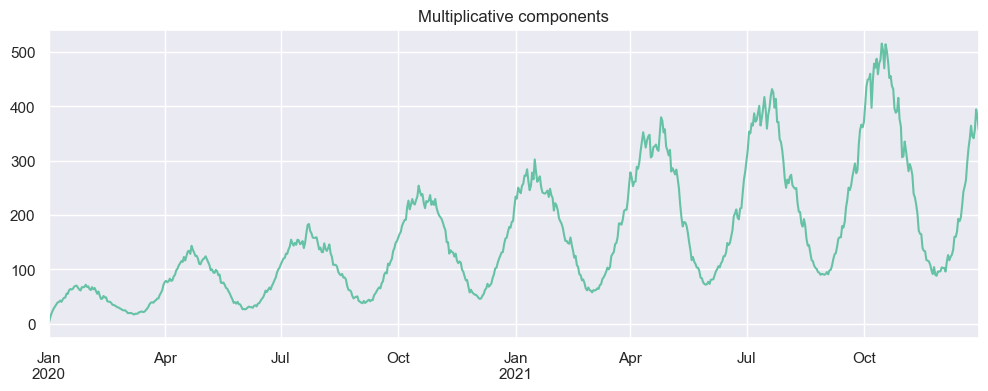

In [81]:
ts = rn * lt * season
dates = pd.date_range(start="01-01-2020", periods=nobs, freq="D") 
df = pd.DataFrame(data=ts, index=dates)
df.plot(figsize=(12, 4), legend=False, title="Multiplicative components")

# Classical decomposition

<Axes: >

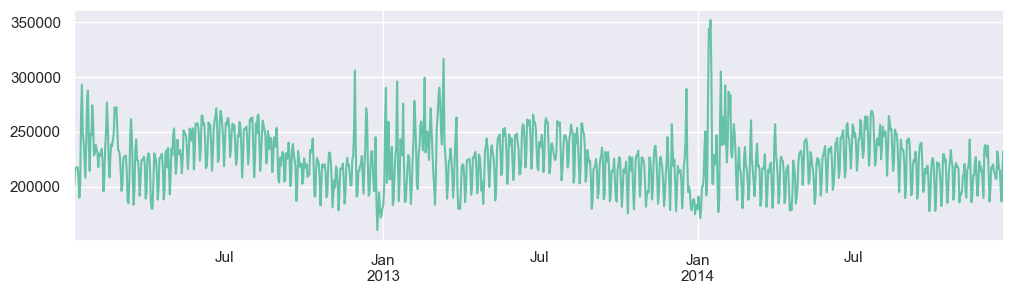

In [82]:
df = pd.read_csv("https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/vic_electricity.csv",
                 parse_dates=["Time"], index_col="Time", usecols=["Time", "Demand"])

# remove the time zone information
df.index = pd.DatetimeIndex([i.replace(tzinfo=None) for i in df.index])

# downsample into monthly observations
ts = df["Demand"].resample("D").sum()
ts = ts[(ts.index > datetime.datetime(2012, 1, 7)) & (ts.index < datetime.datetime(2014, 12, 24))]
ts.plot(figsize=(12, 3), use_index=True)

In [83]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [84]:
# use an additive model, the seasonal period is 7 (weekly seasonality)
res = seasonal_decompose(ts, model='additive', period=7)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

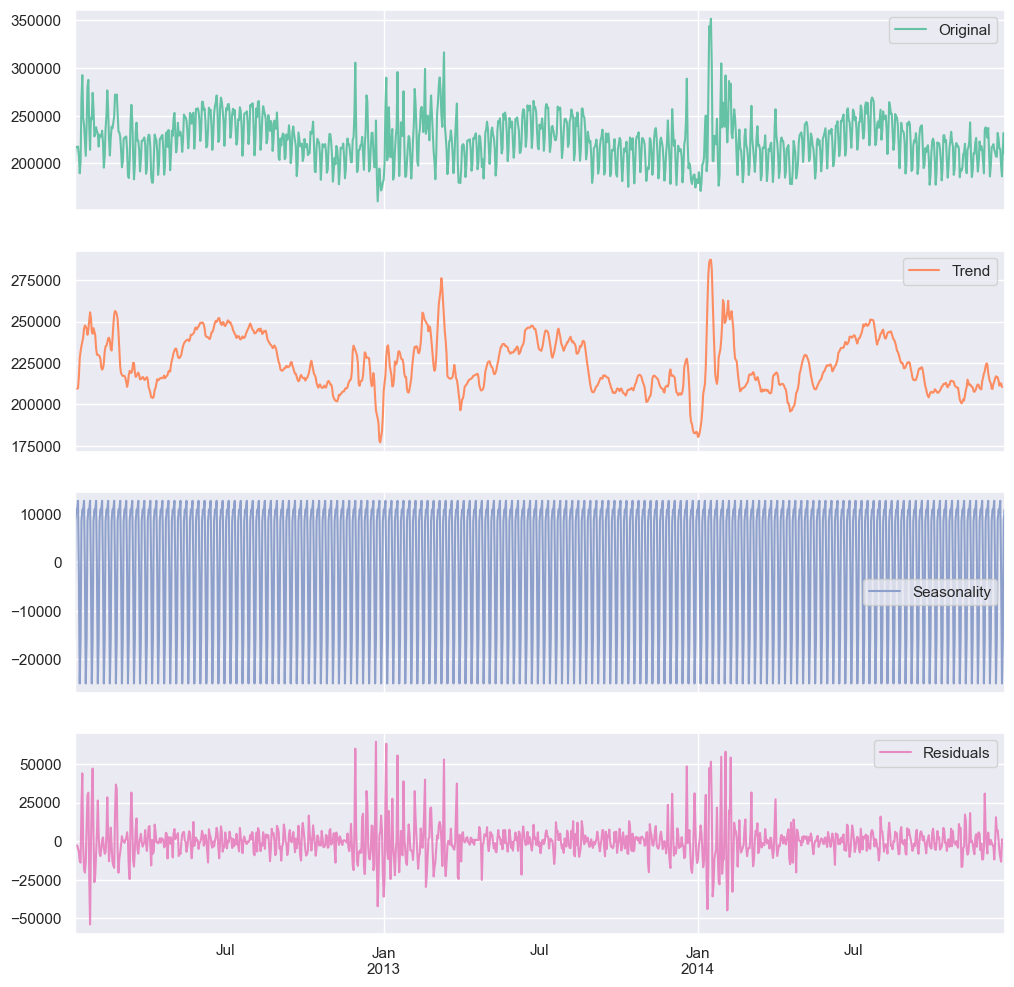

In [87]:
tdf = pd.DataFrame(index=ts.index)
tdf["Original"] = ts
tdf["Trend"] = res.trend
tdf['Seasonality'] = res.seasonal
tdf['Residuals'] = res.resid
tdf.plot(subplots=True, figsize=(12, 12))

# STL

In [ ]:
from statsmodels.tsa.seasonal import STL

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

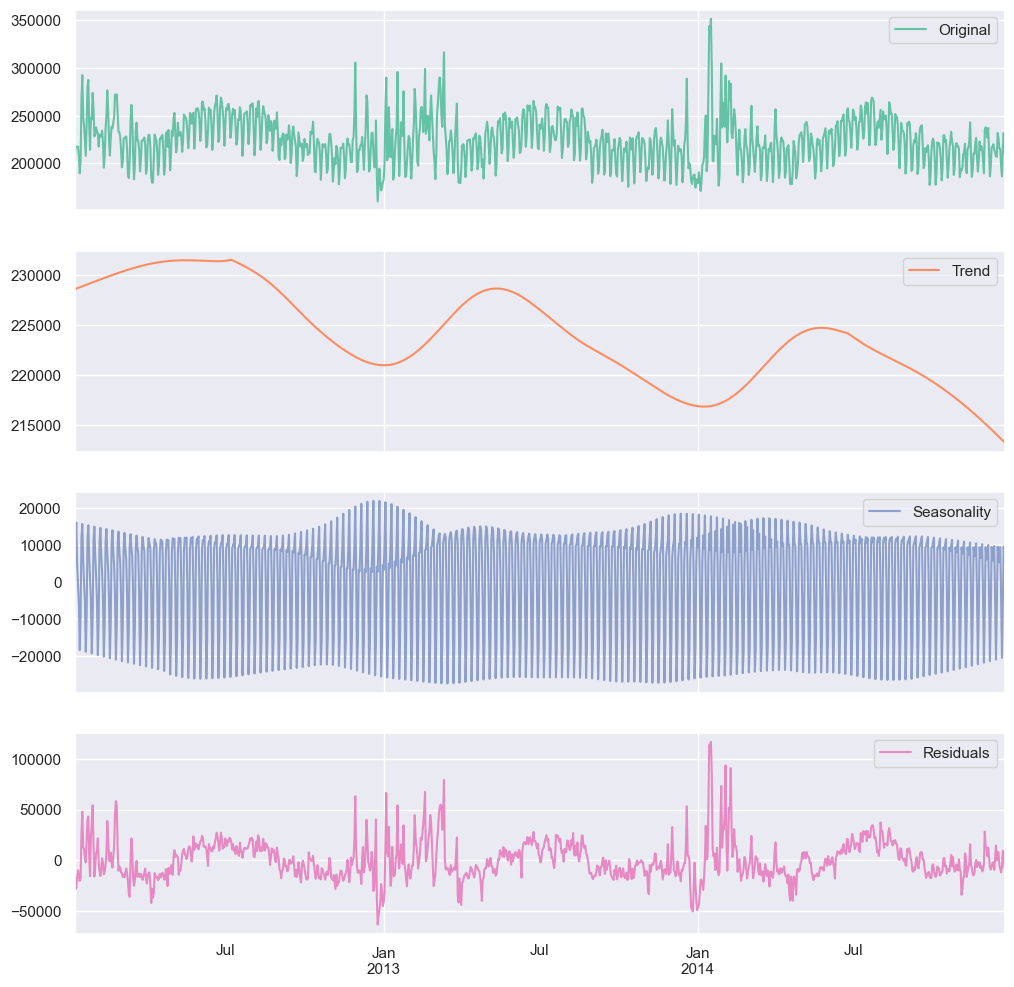

In [91]:
# period is the seasonal period
# seasonal is the window to estimate seasonality
# trend is the window to estimate trend
stl = STL(ts, period=7, seasonal=31, trend=365)
res = stl.fit()

tdf = pd.DataFrame(index=ts.index)
tdf["Original"] = ts
tdf["Trend"] = res.trend
tdf['Seasonality'] = res.seasonal
tdf['Residuals'] = res.resid
tdf.plot(subplots=True, figsize=(12, 12))

# MSTL

In [92]:
from statsmodels.tsa.seasonal import MSTL

In [93]:
mstl = MSTL(
    ts,
    periods=(7, 365),  # multiple seasonal periods
    windows=(31, 365), # multiple seasonal windows
    stl_kwargs={"trend": 367}  # STL args
)

res = mstl.fit()

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

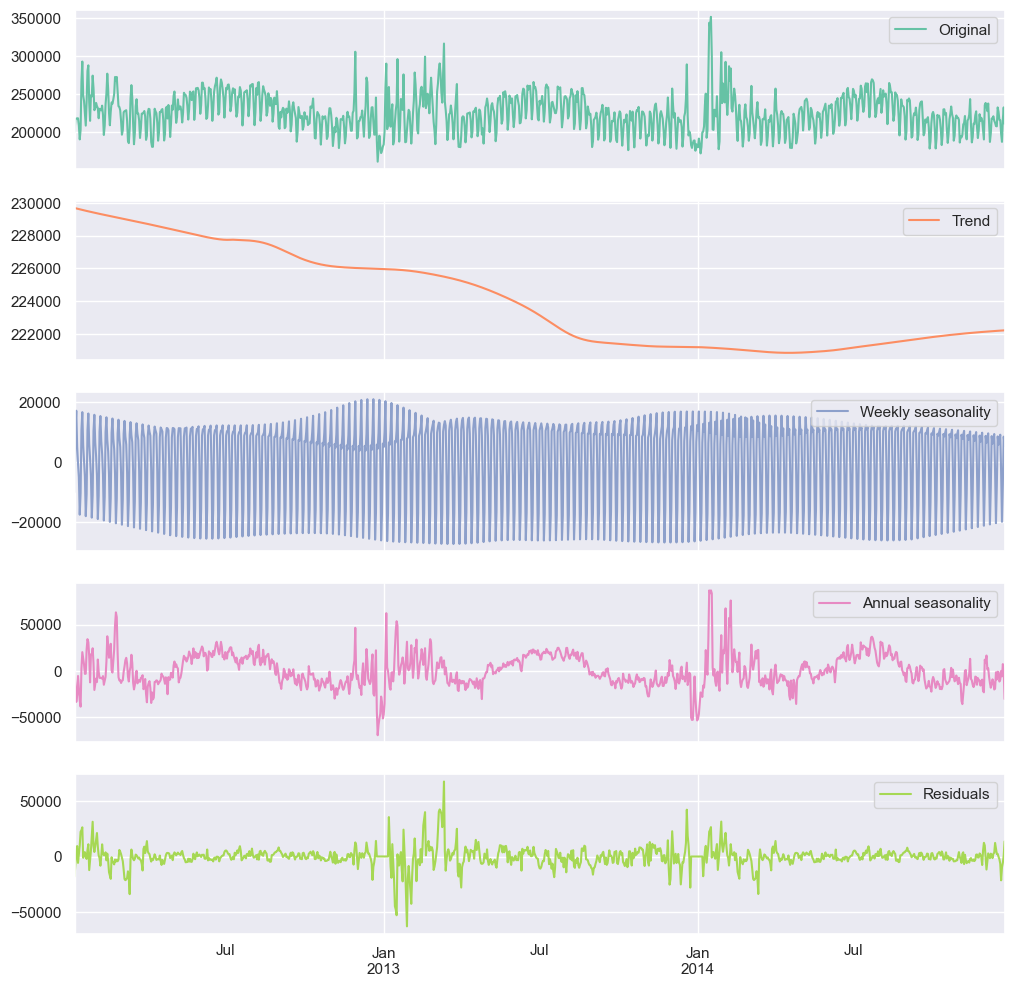

In [95]:
tdf = pd.DataFrame(index=ts.index)
tdf["Original"] = ts
tdf["Trend"] = res.trend
tdf['Weekly seasonality'] = res.seasonal.iloc[:,0]
tdf['Annual seasonality'] = res.seasonal.iloc[:,1]
tdf['Residuals'] = res.resid
tdf.plot(subplots=True, figsize=(12, 12))